In [68]:
# CELDA 1
# Importar librerías necesarias

import torch
import pickle
import numpy as np

from huggingface_hub import hf_hub_download

# Modelo EEGNet implementado en braindecode
from braindecode.models import EEGNetv4

# Métricas
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [69]:
# CELDA 2
# Elegimos uno de los modelos disponibles en el repositorio

MODEL_NAME = "EEGNetv4_Lee2019_MI"

# Descargar configuración del modelo
path_kwargs = hf_hub_download(
    repo_id="PierreGtch/EEGNetv4",
    filename=f"{MODEL_NAME}/kwargs.pkl"
)

# Descargar pesos entrenados
path_params = hf_hub_download(
    repo_id="PierreGtch/EEGNetv4",
    filename=f"{MODEL_NAME}/model-params.pkl"
)

In [70]:
# CELDA 3
# Reconstruir el modelo exactamente como fue entrenado

with open(path_kwargs, "rb") as f:
    kwargs = pickle.load(f)

module_cls = kwargs["module_cls"]
module_kwargs = kwargs["module_kwargs"]

# Crear el modelo
model = module_cls(**module_kwargs)

# Cargar pesos
params = torch.load(path_params, map_location="cpu")
model.load_state_dict(params)

model.eval()

print("Modelo cargado correctamente")

Modelo cargado correctamente


In [92]:
# CELDA 4
# Cargar dataset real usando MOABB

from moabb.datasets import Zhou2016
from moabb.paradigms import MotorImagery

dataset = Zhou2016()

paradigm = MotorImagery(
    channels=["C3", "Cz", "C4"],
    n_classes=2
)

X, y, metadata = paradigm.get_data(dataset)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

print("Shape dataset:", X.shape)

Choosing from all possible events


Shape dataset: (1800, 3, 1251)


In [95]:
# CELDA 5
# Preparar datos y convertir etiquetas a números

from sklearn.preprocessing import LabelEncoder

# convertir datos a tensor
X_torch = torch.tensor(X).float()

# codificar etiquetas
encoder = LabelEncoder()
y_np = encoder.fit_transform(y)

print("Clases:", encoder.classes_)
print("Shape X:", X_torch.shape)
print("Shape y:", y_np.shape)

Clases: [0 1 2]
Shape X: torch.Size([1800, 3, 1251])
Shape y: (1800,)


In [96]:
# CELDA 6 corregida

with torch.no_grad():

    logits = model(X_torch)

    if logits.ndim == 3:
        logits = logits.mean(dim=2)

    preds = torch.argmax(logits, dim=1)

    preds = preds.cpu().numpy().ravel()   # <- IMPORTANTE

print("Predicciones shape:", preds.shape)

Predicciones shape: (1800,)


In [97]:
# CELDA 7

from sklearn.metrics import accuracy_score

acc = accuracy_score(y_np, preds)

print("Accuracy:", acc)

Accuracy: 0.47


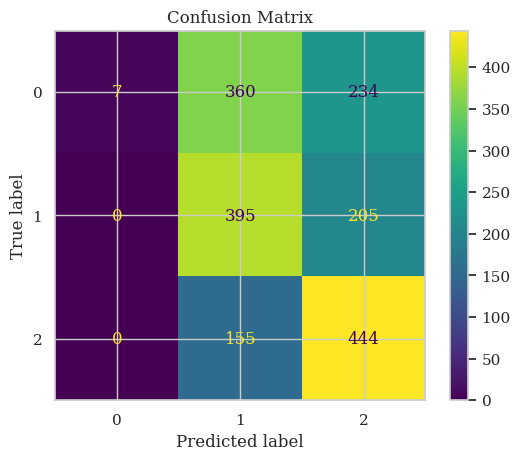

In [98]:
# CELDA 8

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# asegurar tipos correctos
y_true = y_np.astype(int).ravel()
y_pred = preds.astype(int).ravel()

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot()

plt.title("Confusion Matrix")
plt.show()

In [105]:
# CELDA 9
# Evaluar todos los modelos del repositorio

from sklearn.metrics import accuracy_score

models_repo = [
    "EEGNetv4_BNCI2014001",
    "EEGNetv4_BNCI2014004",
    "EEGNetv4_BNCI2015001",
    "EEGNetv4_BNCI2015004",
    "EEGNetv4_Cho2017",
    "EEGNetv4_Lee2019_MI",
    "EEGNetv4_Ofner2017",
    "EEGNetv4_PhysionetMI",
    "EEGNetv4_Schirrmeister2017",
    "EEGNetv4_Weibo2014",
    "EEGNetv4_Zhou2016"
]

results = {}

for model_name in models_repo:

    print("\nEvaluando:", model_name)

    path_kwargs = hf_hub_download(
        repo_id="PierreGtch/EEGNetv4",
        filename=f"{model_name}/kwargs.pkl"
    )

    path_params = hf_hub_download(
        repo_id="PierreGtch/EEGNetv4",
        filename=f"{model_name}/model-params.pkl"
    )

    # reconstruir modelo
    with open(path_kwargs, "rb") as f:
        kwargs = pickle.load(f)

    module_cls = kwargs["module_cls"]
    module_kwargs = kwargs["module_kwargs"]

    model = module_cls(**module_kwargs)

    # info rápida del modelo
    n_classes_model = model.conv_classifier.out_channels
    print(module_kwargs)

    params = torch.load(path_params, map_location="cpu")
    model.load_state_dict(params)

    model.eval()

    # INFERENCIA
    with torch.no_grad():

        logits = model(X_torch)

        # algunos modelos devuelven predicciones por ventana temporal
        if logits.ndim == 3:
            logits = logits.mean(dim=2)

        preds = torch.argmax(logits, dim=1).cpu().numpy().ravel()

    acc = accuracy_score(y_np, preds)

    results[model_name] = acc

print("\nRESULTADOS")
print(results)


Evaluando: EEGNetv4_BNCI2014001
{'in_chans': 3, 'n_classes': 4, 'input_window_samples': 385, 'drop_prob': 0.25}

Evaluando: EEGNetv4_BNCI2014004
{'in_chans': 3, 'n_classes': 2, 'input_window_samples': 385, 'drop_prob': 0.25}

Evaluando: EEGNetv4_BNCI2015001
{'in_chans': 3, 'n_classes': 2, 'input_window_samples': 385, 'drop_prob': 0.25}

Evaluando: EEGNetv4_BNCI2015004
{'in_chans': 3, 'n_classes': 5, 'input_window_samples': 385, 'drop_prob': 0.25}

Evaluando: EEGNetv4_Cho2017
{'in_chans': 3, 'n_classes': 2, 'input_window_samples': 385, 'drop_prob': 0.25}

Evaluando: EEGNetv4_Lee2019_MI
{'in_chans': 3, 'n_classes': 2, 'input_window_samples': 385, 'drop_prob': 0.25}

Evaluando: EEGNetv4_Ofner2017
{'in_chans': 3, 'n_classes': 7, 'input_window_samples': 385, 'drop_prob': 0.25}

Evaluando: EEGNetv4_PhysionetMI
{'in_chans': 3, 'n_classes': 5, 'input_window_samples': 385, 'drop_prob': 0.25}

Evaluando: EEGNetv4_Schirrmeister2017
{'in_chans': 3, 'n_classes': 4, 'input_window_samples': 385, 'dr

In [100]:
# CELDA 10

for k, v in results.items():
    print(k, "accuracy:", round(v,3))

EEGNetv4_BNCI2014001 accuracy: 0.349
EEGNetv4_BNCI2014004 accuracy: 0.333
EEGNetv4_BNCI2015001 accuracy: 0.42
EEGNetv4_BNCI2015004 accuracy: 0.001
EEGNetv4_Cho2017 accuracy: 0.334
EEGNetv4_Lee2019_MI accuracy: 0.307
EEGNetv4_Ofner2017 accuracy: 0.0
EEGNetv4_PhysionetMI accuracy: 0.0
EEGNetv4_Schirrmeister2017 accuracy: 0.332
EEGNetv4_Weibo2014 accuracy: 0.0
EEGNetv4_Zhou2016 accuracy: 0.47


In [106]:
print(X_torch.mean(), X_torch.std())
print(torch.min(X_torch), torch.max(X_torch))

print(np.unique(y_np, return_counts=True))

tensor(5.6280e-05) tensor(5.1527)
tensor(-609.8408) tensor(319.6511)
(array([0, 1, 2]), array([601, 600, 599]))
